# 📝 Text Preprocessing — NLP Basics

> **Folder:** `10_Natural_Language_Processing_Basics`
> **Notebook:** `text_preprocessing.ipynb`
> **Author:** Hamna Munir

---

## Objectives

- Clean and normalize raw text data
- Apply tokenization, stopword removal, stemming, lemmatization
- Build Bag of Words and TF-IDF feature matrices
- Encode text with word embeddings (Word2Vec, FastText)
- Build a complete NLP preprocessing pipeline

---

## Techniques Covered

| # | Technique | Key Insight |
|---|-----------|-------------|
| 1 | Dataset Setup | Synthetic text corpus |
| 2 | Basic Cleaning | Lowercase, punctuation, HTML, URLs |
| 3 | Tokenization | Word and sentence tokenization |
| 4 | Stopword Removal | Remove high-frequency noise words |
| 5 | Stemming | Reduce words to root form (rule-based) |
| 6 | Lemmatization | Reduce to dictionary base form |
| 7 | Bag of Words | CountVectorizer |
| 8 | TF-IDF | Term Frequency-Inverse Document Frequency |
| 9 | N-grams | Bigrams and trigrams |
| 10 | Word2Vec Embeddings | Dense semantic vectors |
| 11 | Full Pipeline | End-to-end preprocessing |
| 12 | Summary and Golden Rules | Key takeaways |


---
## 0. Setup and Imports

In [1]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline

# NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.stem import WordNetLemmatizer

# Optional: gensim for Word2Vec
try:
    from gensim.models import Word2Vec
    GENSIM = True
except ImportError:
    GENSIM = False
    print("gensim not installed: pip install gensim")

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid', font_scale=1.05)

COLORS = {
    'primary'  : '#2E86AB',
    'secondary': '#E84855',
    'accent'   : '#3BB273',
    'warning'  : '#F18F01',
    'purple'   : '#7B2D8B',
    'palette'  : ['#2E86AB','#E84855','#3BB273','#F18F01','#7B2D8B','#F4D35E'],
}
print('Libraries loaded successfully!')

gensim not installed: pip install gensim
Libraries loaded successfully!


---
## 1. Dataset Setup

We create a synthetic text corpus covering different topics and writing styles,
with labels for a binary sentiment classification task (positive=1, negative=0).


In [2]:
np.random.seed(42)

raw_texts = [
    "I absolutely LOVE this product!!! It's amazing and works perfectly :)",
    "Terrible experience. The item broke after 2 days. Very disappointed!!!",
    "Machine learning is transforming the field of artificial intelligence.",
    "The weather today is <b>sunny</b> and warm. Visit https://weather.com",
    "Natural language processing helps computers understand human language.",
    "This movie was AWFUL. Waste of my time and money... never again.",
    "Great service! Fast delivery and excellent packaging. 5 stars!",
    "I can't believe how bad this was... the worst purchase I've ever made!",
    "Deep learning models require large amounts of training data to work well.",
    "The restaurant's food quality has improved significantly over the years.",
    "Running, ran, runs - all forms of the verb run in different tenses.",
    "Studies show that regular exercise improves mental health and well-being.",
    "The    text   has    extra   spaces    and	tabs	that need cleaning.",
    "Don't, won't, can't - contractions are common in informal English writing.",
    "Python is widely used for data science, ML, and AI applications today.",
    "Absolutely fantastic! Best product I have ever bought in my entire life.",
    "Shipping was slow and customer service was completely unhelpful. Awful!",
    "The algorithm achieved state-of-the-art performance on benchmark datasets.",
    "Beautiful design and excellent build quality. Very happy with my purchase!",
    "Broken on arrival. Requested refund but no response from seller yet.",
]

labels = [1,0,1,1,1,0,1,0,1,1,1,1,1,1,1,1,0,1,1,0]

df = pd.DataFrame({'text': raw_texts, 'label': labels})
df['label_name'] = df['label'].map({1:'positive', 0:'negative'})

print(f"Dataset shape    : {df.shape}")
print(f"Class distribution: {dict(df['label_name'].value_counts())}")
print()
print("Sample texts:")
print(df[['text','label_name']].head(6).to_string(index=False))

Dataset shape    : (20, 3)
Class distribution: {'positive': 15, 'negative': 5}

Sample texts:
                                                                  text label_name
 I absolutely LOVE this product!!! It's amazing and works perfectly :)   positive
Terrible experience. The item broke after 2 days. Very disappointed!!!   negative
Machine learning is transforming the field of artificial intelligence.   positive
 The weather today is <b>sunny</b> and warm. Visit https://weather.com   positive
Natural language processing helps computers understand human language.   positive
      This movie was AWFUL. Waste of my time and money... never again.   negative


---
## 2. Basic Text Cleaning

Raw text is messy. Before any NLP, we remove noise:
- HTML tags
- URLs and email addresses
- Punctuation and special characters
- Extra whitespace
- Convert to lowercase


In [3]:
def clean_text(text, lowercase=True, remove_html=True,
               remove_urls=True, remove_punctuation=True,
               remove_numbers=False):
    """
    Basic text cleaning pipeline.

    Args:
        text               : Raw input string
        lowercase          : Convert to lowercase
        remove_html        : Strip HTML tags
        remove_urls        : Remove URLs and emails
        remove_punctuation : Remove punctuation characters
        remove_numbers     : Remove digit characters

    Returns:
        Cleaned string
    """
    if not isinstance(text, str):
        return ''

    # HTML tags
    if remove_html:
        text = re.sub(r'<[^>]+>', ' ', text)

    # URLs
    if remove_urls:
        text = re.sub(r'http\S+|www\.\S+', ' ', text)
        text = re.sub(r'\S+@\S+', ' ', text)

    # Lowercase
    if lowercase:
        text = text.lower()

    # Contractions (basic expansion)
    contractions = {
        "won't": "will not", "can't": "cannot", "don't": "do not",
        "doesn't": "does not", "didn't": "did not", "isn't": "is not",
        "aren't": "are not", "wasn't": "was not", "weren't": "were not",
        "i'm": "i am", "i've": "i have", "i'll": "i will",
        "i'd": "i would", "it's": "it is", "that's": "that is",
        "there's": "there is", "they're": "they are", "they've": "they have",
    }
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)

    # Punctuation
    if remove_punctuation:
        text = text.translate(str.maketrans('', '', string.punctuation))

    # Numbers
    if remove_numbers:
        text = re.sub(r'\d+', ' ', text)

    # Whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


df['text_clean'] = df['text'].apply(clean_text)

print("Before vs After Cleaning:")
compare = df[['text', 'text_clean']].head(6)
for i, row in compare.iterrows():
    print(f"\n  Original : {row['text']}")
    print(f"  Cleaned  : {row['text_clean']}")

Before vs After Cleaning:

  Original : I absolutely LOVE this product!!! It's amazing and works perfectly :)
  Cleaned  : i absolutely love this product it is amazing and works perfectly

  Original : Terrible experience. The item broke after 2 days. Very disappointed!!!
  Cleaned  : terrible experience the item broke after 2 days very disappointed

  Original : Machine learning is transforming the field of artificial intelligence.
  Cleaned  : machine learning is transforming the field of artificial intelligence

  Original : The weather today is <b>sunny</b> and warm. Visit https://weather.com
  Cleaned  : the weather today is sunny and warm visit

  Original : Natural language processing helps computers understand human language.
  Cleaned  : natural language processing helps computers understand human language

  Original : This movie was AWFUL. Waste of my time and money... never again.
  Cleaned  : this movie was awful waste of my time and money never again


---
## 3. Tokenization

Tokenization splits text into individual units (tokens).
- **Word tokenization**: split into words
- **Sentence tokenization**: split into sentences


Word Tokenization:
  [0] ['i', 'absolutely', 'love', 'this', 'product', 'it', 'is', 'amazing', 'and', 'works', 'perfectly']
  [1] ['terrible', 'experience', 'the', 'item', 'broke', 'after', '2', 'days', 'very', 'disappointed']
  [2] ['machine', 'learning', 'is', 'transforming', 'the', 'field', 'of', 'artificial', 'intelligence']
  [3] ['the', 'weather', 'today', 'is', 'sunny', 'and', 'warm', 'visit']

Sentence Tokenization:
  Sentence 1: Machine learning is amazing.
  Sentence 2: It helps solve complex problems.
  Sentence 3: Many industries are adopting it rapidly.

Token statistics:
  Mean tokens per doc  : 10.7
  Min tokens per doc   : 8
  Max tokens per doc   : 15
  Total tokens         : 213
  Unique vocabulary    : 158


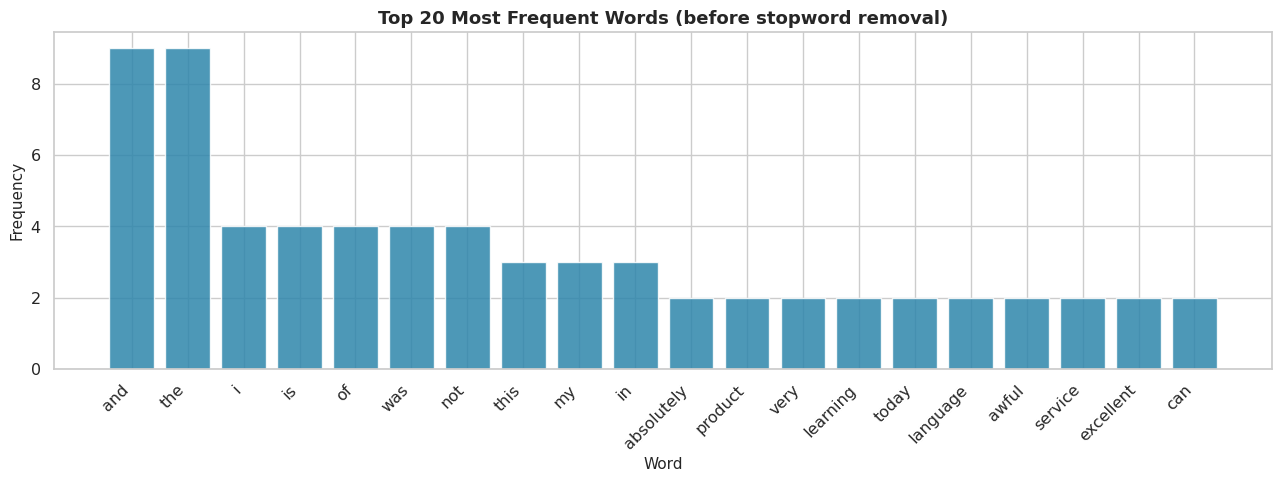

In [4]:
# Word tokenization
df['tokens'] = df['text_clean'].apply(word_tokenize)

# Sentence tokenization on a longer example
sample = ("Machine learning is amazing. It helps solve complex problems. "
          "Many industries are adopting it rapidly.")
sentences = sent_tokenize(sample)

print("Word Tokenization:")
for i in range(4):
    print(f"  [{i}] {df['tokens'].iloc[i]}")

print()
print("Sentence Tokenization:")
for i, sent in enumerate(sentences):
    print(f"  Sentence {i+1}: {sent}")

print()
print("Token statistics:")
token_lengths = df['tokens'].apply(len)
print(f"  Mean tokens per doc  : {token_lengths.mean():.1f}")
print(f"  Min tokens per doc   : {token_lengths.min()}")
print(f"  Max tokens per doc   : {token_lengths.max()}")

# Vocabulary
all_tokens = [tok for tokens in df['tokens'] for tok in tokens]
vocab       = set(all_tokens)
print(f"  Total tokens         : {len(all_tokens)}")
print(f"  Unique vocabulary    : {len(vocab)}")

# Word frequency plot
freq = Counter(all_tokens)
top20 = freq.most_common(20)

fig, ax = plt.subplots(figsize=(13, 5))
words, counts = zip(*top20)
ax.bar(words, counts, color=COLORS['primary'], alpha=0.85, edgecolor='white')
ax.set_xlabel('Word', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Top 20 Most Frequent Words (before stopword removal)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 4. Stopword Removal

Stopwords are high-frequency function words (the, is, in, a, an) that carry
little semantic meaning. Removing them reduces noise and dimensionality.

Note: For some tasks (sentiment analysis, NER) stopwords may be meaningful.
Always evaluate whether removal helps on your specific task.


NLTK English stopwords: 198
Sample: ['both', 'i', "it's", 'to', "should've", 'them', 'then', 'so', "they'll", 'am', 'his', 'if', "she'll", 'my', 'of', 'our', 'between', 'this', 'its', 'on']

Before vs After Stopword Removal:

  Doc 0:
  Before (11): ['i', 'absolutely', 'love', 'this', 'product', 'it', 'is', 'amazing', 'and', 'works', 'perfectly']
  After  (6): ['absolutely', 'love', 'product', 'amazing', 'works', 'perfectly']
  Removed: {'i', 'this', 'is', 'and', 'it'}

  Doc 1:
  Before (10): ['terrible', 'experience', 'the', 'item', 'broke', 'after', '2', 'days', 'very', 'disappointed']
  After  (6): ['terrible', 'experience', 'item', 'broke', 'days', 'disappointed']
  Removed: {'the', 'after', 'very', '2'}

  Doc 2:
  Before (9): ['machine', 'learning', 'is', 'transforming', 'the', 'field', 'of', 'artificial', 'intelligence']
  After  (6): ['machine', 'learning', 'transforming', 'field', 'artificial', 'intelligence']
  Removed: {'the', 'of', 'is'}

Mean token reduction: 34.3%


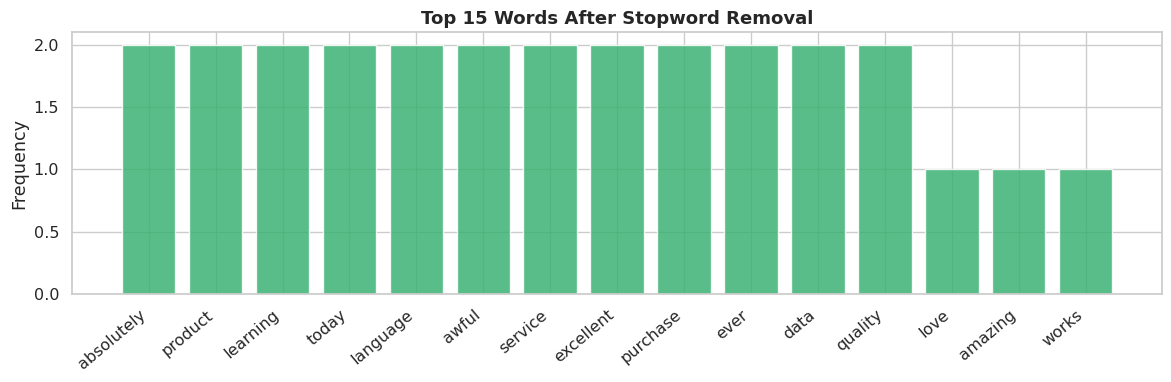

In [5]:
STOPWORDS = set(stopwords.words('english'))
print(f"NLTK English stopwords: {len(STOPWORDS)}")
print(f"Sample: {list(STOPWORDS)[:20]}")

def remove_stopwords(tokens, stop_words=STOPWORDS):
    return [tok for tok in tokens if tok not in stop_words and len(tok) > 1]

df['tokens_no_stop'] = df['tokens'].apply(remove_stopwords)

# Before vs after comparison
print()
print("Before vs After Stopword Removal:")
for i in range(3):
    before = df['tokens'].iloc[i]
    after  = df['tokens_no_stop'].iloc[i]
    removed = set(before) - set(after)
    print(f"\n  Doc {i}:")
    print(f"  Before ({len(before)}): {before}")
    print(f"  After  ({len(after)}): {after}")
    print(f"  Removed: {removed}")

# Token reduction stats
before_len = df['tokens'].apply(len)
after_len  = df['tokens_no_stop'].apply(len)
reduction  = ((before_len - after_len) / before_len * 100).mean()
print(f"\nMean token reduction: {reduction:.1f}%")

# Top words after stopword removal
all_no_stop = [t for tokens in df['tokens_no_stop'] for t in tokens]
freq_no_stop = Counter(all_no_stop)
top15_no_stop = freq_no_stop.most_common(15)

fig, ax = plt.subplots(figsize=(12, 4))
words2, counts2 = zip(*top15_no_stop)
ax.bar(words2, counts2, color=COLORS['accent'], alpha=0.85, edgecolor='white')
ax.set_title('Top 15 Words After Stopword Removal',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Frequency')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

---
## 5. Stemming

Stemming reduces words to their root form using rule-based suffix stripping.
It is fast but can produce non-real words (e.g. "studies" -> "studi").

- **Porter Stemmer**: most common, aggressive
- **Snowball Stemmer**: improved Porter, supports multiple languages


In [6]:
porter   = PorterStemmer()
snowball = SnowballStemmer('english')

def stem_tokens(tokens, stemmer=porter):
    return [stemmer.stem(tok) for tok in tokens]

df['tokens_stemmed']  = df['tokens_no_stop'].apply(stem_tokens)

# Demonstrate stemming
demo_words = ['running','runs','ran','easily','fairly','studies',
              'studying','studied','better','computing','happiness']

print("Stemming Comparison:")
print(f"{'Word':<15} {'Porter':<15} {'Snowball':<15}")
print('-' * 45)
for w in demo_words:
    p = porter.stem(w)
    s = snowball.stem(w)
    print(f"{w:<15} {p:<15} {s:<15}")

print()
print("Sample stemmed tokens:")
for i in range(3):
    print(f"  Doc {i}: {df['tokens_stemmed'].iloc[i]}")

Stemming Comparison:
Word            Porter          Snowball       
---------------------------------------------
running         run             run            
runs            run             run            
ran             ran             ran            
easily          easili          easili         
fairly          fairli          fair           
studies         studi           studi          
studying        studi           studi          
studied         studi           studi          
better          better          better         
computing       comput          comput         
happiness       happi           happi          

Sample stemmed tokens:
  Doc 0: ['absolut', 'love', 'product', 'amaz', 'work', 'perfectli']
  Doc 1: ['terribl', 'experi', 'item', 'broke', 'day', 'disappoint']
  Doc 2: ['machin', 'learn', 'transform', 'field', 'artifici', 'intellig']


---
## 6. Lemmatization

Lemmatization reduces words to their dictionary base form (lemma) using
vocabulary and morphological analysis. Produces real words unlike stemming.

- **Better quality** than stemming but slower
- Requires POS (part-of-speech) tags for best results
- "better" -> "good", "ran" -> "run", "studies" -> "study"


In [7]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    """Lemmatize with basic POS tagging for better accuracy."""
    # POS map: J=adj, V=verb, N=noun, R=adverb
    from nltk import pos_tag
    from nltk.corpus import wordnet

    def get_wordnet_pos(tag):
        if tag.startswith('J'):
            return wordnet.ADJ
        elif tag.startswith('V'):
            return wordnet.VERB
        elif tag.startswith('R'):
            return wordnet.ADV
        else:
            return wordnet.NOUN

    tagged = pos_tag(tokens)
    return [lemmatizer.lemmatize(tok, get_wordnet_pos(tag))
            for tok, tag in tagged]

df['tokens_lemma'] = df['tokens_no_stop'].apply(lemmatize_tokens)

# Stem vs Lemma comparison
demo_words2 = ['running','was','better','worse','studies','caring',
               'went','flies','happily','wolves']

print("Stemming vs Lemmatization:")
print(f"{'Word':<12} {'Porter Stem':<16} {'Lemma (noun)':<16} {'Lemma (verb)':<16}")
print('-' * 60)
for w in demo_words2:
    ps  = porter.stem(w)
    ln  = lemmatizer.lemmatize(w, 'n')
    lv  = lemmatizer.lemmatize(w, 'v')
    print(f"{w:<12} {ps:<16} {ln:<16} {lv:<16}")

print()
print("Lemmatized tokens (sample):")
for i in range(3):
    print(f"  Doc {i}: {df['tokens_lemma'].iloc[i]}")

LookupError: 
**********************************************************************
  Resource [93maveraged_perceptron_tagger_eng[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('averaged_perceptron_tagger_eng')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtaggers/averaged_perceptron_tagger_eng[0m

  Searched in:
    - '/home/c5963754-ad9c-4258-b07d-322081901e4a/nltk_data'
    - '/opt/conda/envs/anaconda-2025.12-py312/nltk_data'
    - '/opt/conda/envs/anaconda-2025.12-py312/share/nltk_data'
    - '/opt/conda/envs/anaconda-2025.12-py312/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


---
## 7. Bag of Words (CountVectorizer)

Bag of Words represents documents as vectors of word counts.
It ignores word order but captures word presence and frequency.

- Simple and interpretable
- High dimensional (one feature per vocabulary word)
- Sparse matrix (most entries are 0)


In [ ]:
# Join lemmatized tokens back to string for sklearn vectorizers
df['text_lemma_str'] = df['tokens_lemma'].apply(lambda x: ' '.join(x))

# ── CountVectorizer ────────────────────────────────────────────────────────
bow_vectorizer = CountVectorizer(
    max_features=50,      # top 50 words by frequency
    min_df=1,             # min document frequency
    max_df=0.95,          # ignore words in > 95% of docs
    ngram_range=(1, 1),   # unigrams only
)
X_bow = bow_vectorizer.fit_transform(df['text_lemma_str'])
vocab_bow = bow_vectorizer.get_feature_names_out()

print(f"BoW matrix shape : {X_bow.shape}")
print(f"Vocabulary size  : {len(vocab_bow)}")
print(f"Sparsity         : {(X_bow.nnz / (X_bow.shape[0]*X_bow.shape[1]))*100:.2f}% non-zero")
print(f"Top features     : {list(vocab_bow[:20])}")

# Visualize BoW matrix
bow_df = pd.DataFrame(X_bow.toarray(), columns=vocab_bow)
bow_df['label'] = df['label_name'].values

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(bow_df.drop('label', axis=1).iloc[:, :30],
            cmap='Blues', ax=ax, linewidths=0.3,
            yticklabels=[f"Doc {i}" for i in range(len(df))],
            cbar_kws={'shrink': 0.6})
ax.set_title('Bag of Words Matrix (top 30 features)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature (word)', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

---
## 8. TF-IDF — Term Frequency-Inverse Document Frequency

TF-IDF weights words by how important they are to a document
relative to the entire corpus.

```
TF(t, d)  = count of term t in document d / total terms in d
IDF(t)    = log(N / df(t))   where N = total docs, df(t) = docs containing t
TF-IDF    = TF x IDF
```

- Common words across all docs get LOW weight (low IDF)
- Rare but important words get HIGH weight (high IDF)


In [ ]:
# ── TfidfVectorizer ──────────────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(
    max_features=50,
    min_df=1,
    max_df=0.95,
    ngram_range=(1, 1),
    sublinear_tf=True,     # apply log(1+tf) instead of raw tf
    norm='l2',             # L2 normalize each document vector
)
X_tfidf = tfidf_vectorizer.fit_transform(df['text_lemma_str'])
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Vocabulary size    : {len(vocab_tfidf)}")

# IDF values (high IDF = rare = more discriminative)
idf_series = pd.Series(
    tfidf_vectorizer.idf_, index=vocab_tfidf
).sort_values(ascending=False)

print()
print("Top 10 highest IDF (rarest, most discriminative):")
print(idf_series.head(10).round(4).to_string())
print()
print("Bottom 10 lowest IDF (most common):")
print(idf_series.tail(10).round(4).to_string())

# BoW vs TF-IDF heatmap comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

common_features = list(vocab_bow[:20])
bow_sub  = pd.DataFrame(X_bow.toarray(), columns=vocab_bow)[common_features]
tfidf_sub = pd.DataFrame(
    tfidf_vectorizer.transform(df['text_lemma_str']).toarray(),
    columns=vocab_tfidf
)
tfidf_common = [f for f in common_features if f in tfidf_sub.columns]

sns.heatmap(bow_sub, cmap='Blues', ax=axes[0], linewidths=0.2,
            yticklabels=[f"D{i}" for i in range(len(df))],
            cbar_kws={'shrink':0.6})
axes[0].set_title('Bag of Words (raw counts)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)

if tfidf_common:
    sns.heatmap(tfidf_sub[tfidf_common], cmap='YlOrRd',
                ax=axes[1], linewidths=0.2,
                yticklabels=[f"D{i}" for i in range(len(df))],
                cbar_kws={'shrink':0.6})
    axes[1].set_title('TF-IDF (weighted)', fontsize=12, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle('BoW vs TF-IDF Representation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. N-grams — Capturing Word Sequences

N-grams capture sequences of N consecutive words, preserving local context.
- **Unigram (1)**: single words
- **Bigram (2)**: two consecutive words ("not good", "very fast")
- **Trigram (3)**: three consecutive words ("not very good")

N-grams help capture phrases and negations that unigrams miss.


In [ ]:
ngram_configs = {
    'Unigrams (1,1)' : (1, 1),
    'Bigrams (2,2)'  : (2, 2),
    'Uni+Bi (1,2)'   : (1, 2),
    'Uni+Bi+Tri(1,3)': (1, 3),
}

ngram_results = []
for name, ngram_range in ngram_configs.items():
    vec = TfidfVectorizer(
        max_features=100,
        ngram_range=ngram_range,
        min_df=1, max_df=0.95
    )
    X_ng = vec.fit_transform(df['text_lemma_str'])
    features = vec.get_feature_names_out()
    ngram_results.append({
        'Config'  : name,
        'Features': X_ng.shape[1],
        'Sparsity': f"{(X_ng.nnz/(X_ng.shape[0]*X_ng.shape[1]))*100:.2f}%",
        'Sample'  : list(features[:6]),
    })
    print(f"{name}: {X_ng.shape[1]} features | "
          f"sample: {list(features[:5])}")

# Bigram TF-IDF: top bigrams
bi_vec = TfidfVectorizer(ngram_range=(2,2), max_features=30,
                          min_df=1, max_df=0.95)
X_bi = bi_vec.fit_transform(df['text_lemma_str'])
bi_scores = np.asarray(X_bi.sum(axis=0)).ravel()
bi_features = bi_vec.get_feature_names_out()
top_bi = sorted(zip(bi_features, bi_scores), key=lambda x: -x[1])[:15]

fig, ax = plt.subplots(figsize=(12, 5))
bi_words, bi_vals = zip(*top_bi)
ax.barh(bi_words, bi_vals, color=COLORS['warning'], alpha=0.85, edgecolor='white')
ax.set_xlabel('Total TF-IDF Score', fontsize=11)
ax.set_title('Top 15 Bigrams by TF-IDF Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Word2Vec Embeddings

Word2Vec learns dense semantic vectors where similar words are close together.
After training, we create document embeddings by averaging word vectors.


In [ ]:
if GENSIM:
    # ── Train Word2Vec on our corpus ──────────────────────────────────────
    w2v_model = Word2Vec(
        sentences=df['tokens_lemma'].tolist(),
        vector_size=50,     # embedding dimension
        window=3,           # context window size
        min_count=1,        # minimum word frequency
        sg=1,               # 1=skip-gram, 0=CBOW
        workers=1,
        epochs=100,
        seed=42,
    )

    print(f"Word2Vec vocabulary size: {len(w2v_model.wv.key_to_index)}")
    print(f"Embedding dimension     : {w2v_model.vector_size}")
    print()

    # Show some word vectors
    sample_words = ['good','bad','learn','product','fast']
    available    = [w for w in sample_words if w in w2v_model.wv]
    if available:
        print(f"Sample vectors (first 8 dims):")
        for w in available:
            vec = w2v_model.wv[w][:8].round(3)
            print(f"  {w:<10}: {vec}")

    # Similar words
    print()
    for word in available[:2]:
        try:
            similar = w2v_model.wv.most_similar(word, topn=3)
            print(f"Most similar to '{word}': {similar}")
        except Exception:
            pass

    # Document embedding = mean of word vectors
    def doc_to_vec(tokens, model, dim=50):
        vecs = [model.wv[t] for t in tokens if t in model.wv]
        if not vecs:
            return np.zeros(dim)
        return np.mean(vecs, axis=0)

    X_w2v = np.vstack([doc_to_vec(tokens, w2v_model)
                        for tokens in df['tokens_lemma']])
    print(f"Document embedding matrix shape: {X_w2v.shape}")

    # PCA visualization of doc embeddings
    from sklearn.decomposition import PCA
    pca  = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_w2v)

    fig, ax = plt.subplots(figsize=(9, 6))
    for label, color in [(1, COLORS['accent']), (0, COLORS['secondary'])]:
        mask = df['label'].values == label
        name = 'positive' if label == 1 else 'negative'
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color, alpha=0.8, s=100, edgecolors='white',
                   label=name, zorder=3)

    for i, row in df.iterrows():
        ax.annotate(str(i), (X_2d[i, 0], X_2d[i, 1]),
                    textcoords='offset points', xytext=(5, 3), fontsize=7)

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
    ax.set_title('Word2Vec Document Embeddings — PCA 2D Projection',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

else:
    print("gensim not available - skipping Word2Vec")
    print("Install with: pip install gensim")

---
## 11. Full NLP Pipeline — End-to-End

Build a complete sklearn Pipeline:
clean text -> TF-IDF vectorization -> Logistic Regression classifier.
Evaluate with cross-validation to get reliable performance estimates.


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# ── Preprocessing function for sklearn ──────────────────────────────────
def preprocess_for_sklearn(text):
    """Full preprocessing: clean -> tokenize -> remove stopwords -> lemmatize."""
    cleaned = clean_text(text)
    tokens  = word_tokenize(cleaned)
    tokens  = remove_stopwords(tokens)
    tokens  = lemmatize_tokens(tokens)
    return ' '.join(tokens)

X_text = df['text'].values
y      = df['label'].values
X_preprocessed = np.array([preprocess_for_sklearn(t) for t in X_text])

# ── Pipeline: TF-IDF + Logistic Regression ──────────────────────────────
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=100,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=1,
        max_df=0.95,
    )),
    ('clf', LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=42,
        solver='lbfgs',
    )),
])

# ── Cross-validation ─────────────────────────────────────────────────────
skf    = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X_preprocessed, y,
                          cv=skf, scoring='accuracy')

print("Full NLP Pipeline: TF-IDF (1,2-gram) + Logistic Regression")
print(f"  CV Accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")
print(f"  Fold scores: {scores.round(4)}")

# ── Train/test split evaluation ──────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_preprocessed, y, test_size=0.3,
    stratify=y, random_state=42
)
pipeline.fit(X_tr, y_tr)
y_pred = pipeline.predict(X_te)

print()
print(f"Train size : {len(X_tr)} | Test size: {len(X_te)}")
print(f"Test Accuracy: {accuracy_score(y_te, y_pred):.4f}")
print()
print("Classification Report:")
print(classification_report(y_te, y_pred,
                             target_names=['negative','positive']))

# Feature importance (top TF-IDF features by LR coefficient)
tfidf_step = pipeline.named_steps['tfidf']
clf_step   = pipeline.named_steps['clf']
feat_names = tfidf_step.get_feature_names_out()
coefs      = clf_step.coef_[0]

top_pos = pd.Series(coefs, index=feat_names).nlargest(10)
top_neg = pd.Series(coefs, index=feat_names).nsmallest(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(top_pos.index, top_pos.values,
             color=COLORS['accent'], alpha=0.85, edgecolor='white')
axes[0].set_title('Top 10 Positive Features (push toward positive class)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('LR Coefficient')

axes[1].barh(top_neg.index, top_neg.values,
             color=COLORS['secondary'], alpha=0.85, edgecolor='white')
axes[1].set_title('Top 10 Negative Features (push toward negative class)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('LR Coefficient')

plt.suptitle('TF-IDF + LR Pipeline — Feature Coefficients',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. Summary and Golden Rules

| Step | Method | Output |
|------|--------|--------|
| **Cleaning** | Regex, lowercase, HTML removal | Clean string |
| **Tokenization** | word_tokenize | List of tokens |
| **Stopwords** | NLTK stopwords list | Filtered tokens |
| **Stemming** | PorterStemmer | Root forms (may not be real words) |
| **Lemmatization** | WordNetLemmatizer + POS | Dictionary base forms |
| **BoW** | CountVectorizer | Sparse count matrix |
| **TF-IDF** | TfidfVectorizer | Sparse weighted matrix |
| **N-grams** | ngram_range=(1,2) | Phrase-aware features |
| **Word2Vec** | gensim Word2Vec | Dense semantic vectors |

### Golden Rules

1. Always clean text before tokenization (lowercase, HTML, URLs)
2. Use lemmatization over stemming when quality matters
3. Stopword removal is task-dependent - test both ways
4. TF-IDF beats raw BoW for most classification tasks
5. N-grams (1,2) usually outperform unigrams alone
6. Use pre-trained embeddings (GloVe, FastText) on small datasets
7. For production use sklearn Pipeline to prevent train/test leakage
8. Always evaluate with cross-validation on small text datasets
9. Inspect top features by coefficient or importance after training
10. For complex tasks use BERT contextual embeddings instead of static ones

---

## Next Steps

- `10_NLP_Basics/word_embeddings.md` - Theory behind Word2Vec, GloVe, BERT
- `10_NLP_Basics/text_classification.ipynb` - Full classification with BERT
- `10_NLP_Basics/sentiment_analysis.ipynb` - Sentiment with transformers
- `06_Feature_Selection/` - Select best text features
